In [1]:
from shared.utils.reproducibility import set_seeds

set_seeds(seed=42)

In [2]:
import os

BASE_PATH = "C:/Users/panaa/Desktop/dipseer"

TRAIN_DIPSEER = os.path.join(BASE_PATH, "train")
VAL_DIPSEER = os.path.join(BASE_PATH, "val")
TEST_DIPSEER = os.path.join(BASE_PATH, "test")

ALLOWED_EXPERIMENTS = [
    "group_01/experiment_01",
    "group_01/experiment_02",
    "group_01/experiment_03",
    "group_01/experiment_04",
    "group_01/experiment_05",
    "group_01/experiment_06",

    "group_02/experiment_01",
    "group_02/experiment_02",
    "group_02/experiment_03",
    "group_02/experiment_04",
    "group_02/experiment_05",
    "group_02/experiment_06",

    "group_03/experiment_01",
    "group_03/experiment_02",
    "group_03/experiment_03",
    "group_03/experiment_04",
    "group_03/experiment_05",
    "group_03/experiment_06",
]

In [3]:
from src.dipseer.dataset.dataset import build_dataset_with_stats

split_paths = {
    "train": TRAIN_DIPSEER,
    "val": VAL_DIPSEER,
    "test": TEST_DIPSEER
}

datasets = build_dataset_with_stats(split_paths, ALLOWED_EXPERIMENTS)


Building train...
train: 5267 sequences

Attention distribution:
1: 1658
0: 2107
2: 1502

Emotion distribution:
0: 2980
1: 295
3: 1767
2: 225

Building val...
val: 1299 sequences

Attention distribution:
1: 468
0: 224
2: 607

Emotion distribution:
0: 733
1: 181
2: 52
3: 333

Building test...
test: 1259 sequences

Attention distribution:
2: 535
1: 461
0: 263

Emotion distribution:
0: 717
1: 71
3: 354
2: 117


In [4]:
X_train, y_emo_train, y_att_train, stats_train = datasets["train"]
X_val, y_emo_val, y_att_val, stats_val = datasets["val"]
X_test, y_emo_test, y_att_test, stats_test = datasets["test"]

print(X_train.shape)
print(y_emo_train.shape)
print(y_att_train.shape)

print("TRAIN min/max:", X_train.min(), X_train.max())
print("VAL min/max:", X_val.min(), X_val.max())
print("TEST min/max:", X_test.min(), X_test.max())

(5267, 20, 1434)
(5267,)
(5267,)
TRAIN min/max: -0.99991053 0.9999947
VAL min/max: -0.9998501 0.99984586
TEST min/max: -0.9999592 0.9999498


In [5]:
import numpy as np

def encode_ordinal(y):
    encoded = []

    for val in y:
        if val == 0:
            encoded.append([0,0])
        elif val == 1:
            encoded.append([1,0])
        elif val == 2:
            encoded.append([1,1])

    return np.array(encoded, dtype=np.float32)

y_att_train_ord = encode_ordinal(y_att_train)
y_att_val_ord = encode_ordinal(y_att_val)
y_att_test_ord = encode_ordinal(y_att_test)

In [6]:
train_data = (X_train, y_emo_train, y_att_train_ord)
val_data = (X_val, y_emo_val, y_att_val_ord)
test_data  = (X_test, y_emo_test, y_att_test_ord)

In [7]:
from dipseer.models.ordinal_model import build_dipseer_model, compile_model, get_callbacks

model = build_dipseer_model()
compile_model(model)
callbacks = get_callbacks()

model.summary()

Model: "Dipseer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 20, 1434)]        0         
                                                                 
 lstm (LSTM)                 (None, 20, 256)           1731584   
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 128)               16512     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 att_output (Dense)          (None, 2)                 130 

In [8]:
history = model.fit(
    X_train,
    y_att_train_ord,
    validation_data=(X_val, y_att_val_ord),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/100
330/330 [==============================] - ETA: 0s - loss: 0.5922 - binary_accuracy: 0.6812
Epoch 1: val_loss improved from inf to 0.66171, saving model to checkpoints/ordinal\best_model.h5
330/330 [==============================] - 64s 185ms/step - loss: 0.5922 - binary_accuracy: 0.6812 - val_loss: 0.6617 - val_binary_accuracy: 0.5600 - lr: 1.0000e-04
Epoch 2/100
330/330 [==============================] - ETA: 0s - loss: 0.5758 - binary_accuracy: 0.6941
Epoch 2: val_loss did not improve from 0.66171
330/330 [==============================] - 53s 160ms/step - loss: 0.5758 - binary_accuracy: 0.6941 - val_loss: 0.7723 - val_binary_accuracy: 0.4950 - lr: 1.0000e-04
Epoch 3/100
330/330 [==============================] - ETA: 0s - loss: 0.5628 - binary_accuracy: 0.7064
Epoch 3: val_loss did not improve from 0.66171
330/330 [==============================] - 60s 180ms/step - loss: 0.5628 - binary_accuracy: 0.7064 - val_loss: 0.7108 - val_binary_accuracy: 0.5065 - lr: 1.0000e-04
E

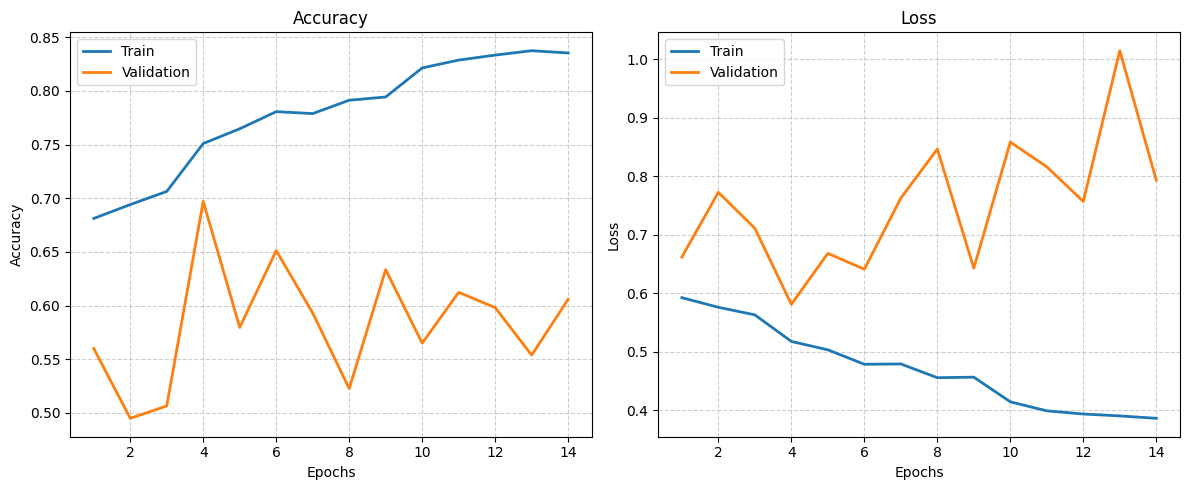

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['binary_accuracy']
    val_acc = history.history['val_binary_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.style.use('default')
    plt.figure(figsize=(12, 5), facecolor='white')

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train', linewidth=2)
    plt.plot(epochs, val_acc, label='Validation', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation', linewidth=2)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [11]:
import numpy as np

def decode_ordinal(pred):
    pred = (pred > 0.5).astype(int)

    decoded = []

    for p in pred:
        if p[0] == 0:
            decoded.append(0)
        elif p[1] == 0:
            decoded.append(1)
        else:
            decoded.append(2)

    return np.array(decoded)


================ TEST METRICS ================

Accuracy : 0.6410
Macro F1 : 0.6092

=========== Classification Report ===========

              precision    recall  f1-score   support

         Low       0.64      0.40      0.49       263
      Medium       0.60      0.67      0.63       461
        High       0.68      0.74      0.71       535

    accuracy                           0.64      1259
   macro avg       0.64      0.60      0.61      1259
weighted avg       0.64      0.64      0.63      1259



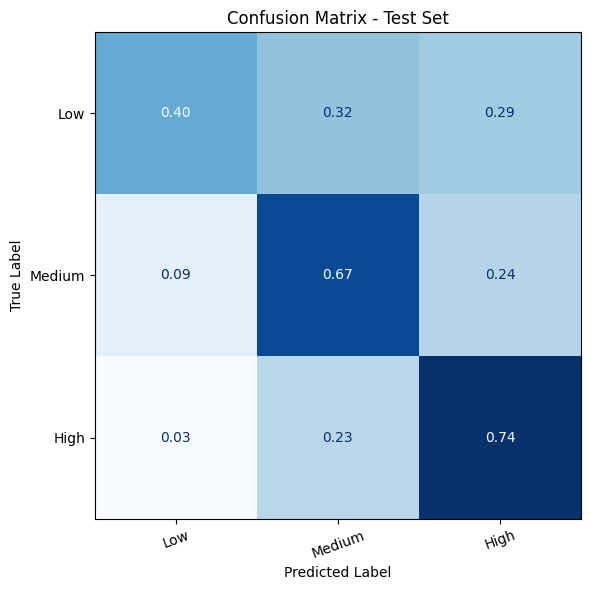

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

ATTENTION_LABELS = ["Low", "Medium", "High"]


def evaluate_on_test(model, X_test, y_test, class_names=ATTENTION_LABELS, normalize='true'):

    y_prob = model.predict(X_test, verbose=0)

    y_pred = decode_ordinal(y_prob)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print("\n================ TEST METRICS ================\n")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    print("\n=========== Classification Report ===========\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=2))

    cm = confusion_matrix(y_test, y_pred, normalize=normalize)

    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='.2f',
        colorbar=False
    )

    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return y_pred, y_prob

y_pred, y_prob = evaluate_on_test(model, X_test, y_att_test)